In [1]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    print(dirname)
    break

/kaggle/input


In [2]:
import os

for item in os.listdir("/kaggle/input"):
    print(item)

datasets


In [3]:
import os

DATASET_DIR = "/kaggle/input/datasets/gillesokhin/nutrition5k-dataset"

for dirname, _, filenames in os.walk(DATASET_DIR):
    if "dish_nutrition_values.csv" in filenames:
        print("Nutrition CSV found at:", os.path.join(dirname, "dish_nutrition_values.csv"))

    if dirname.endswith("realsense_overhead"):
        print("Image root found at:", dirname)

Nutrition CSV found at: /kaggle/input/datasets/gillesokhin/nutrition5k-dataset/dish_nutrition_values.csv
Image root found at: /kaggle/input/datasets/gillesokhin/nutrition5k-dataset/imagery/realsense_overhead


In [4]:
import os
import pandas as pd

nutrition_path = "/kaggle/input/datasets/gillesokhin/nutrition5k-dataset/dish_nutrition_values.csv"
IMAGE_ROOT = "/kaggle/input/datasets/gillesokhin/nutrition5k-dataset/imagery/realsense_overhead"

nutrition_df = pd.read_csv(nutrition_path)

def get_rgb_path(dish_id):
    return os.path.join(IMAGE_ROOT, dish_id, "rgb.png")

nutrition_df["image_path"] = nutrition_df["dish_id"].apply(get_rgb_path)
nutrition_df["image_exists"] = nutrition_df["image_path"].apply(os.path.exists)

print(nutrition_df.shape)
print(nutrition_df["image_exists"].value_counts())
nutrition_df.head()

(4768, 8)
image_exists
True     3244
False    1524
Name: count, dtype: int64


,dish_id,calories,mass,fat,carb,protein,image_path,image_exists
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970,/kaggle/input/datasets/gillesokhin/nutrition5k...,True
1,dish_1562688426,137.569992,88.0,8.256000,5.190000,10.297000,/kaggle/input/datasets/gillesokhin/nutrition5k...,False
2,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593,/kaggle/input/datasets/gillesokhin/nutrition5k...,True
3,dish_1562008979,382.936646,290.0,22.224644,10.173570,35.345387,/kaggle/input/datasets/gillesokhin/nutrition5k...,True
4,dish_1560455030,20.590000,103.0,0.148000,4.625000,0.956000,/kaggle/input/datasets/gillesokhin/nutrition5k...,True


In [5]:
clean_model_df = nutrition_df.dropna(
    subset=["calories", "mass", "fat", "carb", "protein"]
).copy()

clean_model_df = clean_model_df[clean_model_df["image_exists"] == True].copy()

clean_model_df["calorie_quantile_class"] = pd.qcut(
    clean_model_df["calories"],
    q=3,
    labels=[0, 1, 2]
).astype(int)

class_names_map = {
    0: "Low",
    1: "Medium",
    2: "High"
}

clean_model_df["calorie_quantile_label"] = clean_model_df["calorie_quantile_class"].map(class_names_map)

print(clean_model_df.shape)
print(clean_model_df["calorie_quantile_label"].value_counts())
clean_model_df.head()

(3244, 10)
calorie_quantile_label
High      1082
Medium    1081
Low       1081
Name: count, dtype: int64


,dish_id,calories,mass,fat,carb,protein,image_path,image_exists,calorie_quantile_class,calorie_quantile_label
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970,/kaggle/input/datasets/gillesokhin/nutrition5k...,True,1,Medium
2,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593,/kaggle/input/datasets/gillesokhin/nutrition5k...,True,2,High
3,dish_1562008979,382.936646,290.0,22.224644,10.173570,35.345387,/kaggle/input/datasets/gillesokhin/nutrition5k...,True,2,High
4,dish_1560455030,20.590000,103.0,0.148000,4.625000,0.956000,/kaggle/input/datasets/gillesokhin/nutrition5k...,True,0,Low
5,dish_1558372433,74.360001,143.0,0.286000,0.429000,20.020000,/kaggle/input/datasets/gillesokhin/nutrition5k...,True,0,Low


In [6]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [7]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
nutrition_df = pd.read_csv(nutrition_path)

def get_rgb_path(dish_id):
    return os.path.join(IMAGE_ROOT, dish_id, "rgb.png")

nutrition_df["image_path"] = nutrition_df["dish_id"].apply(get_rgb_path)
nutrition_df["image_exists"] = nutrition_df["image_path"].apply(os.path.exists)

print(nutrition_df.shape)
print(nutrition_df["image_exists"].value_counts())
nutrition_df.head()

(4768, 8)
image_exists
True     3244
False    1524
Name: count, dtype: int64


,dish_id,calories,mass,fat,carb,protein,image_path,image_exists
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970,/kaggle/input/datasets/gillesokhin/nutrition5k...,True
1,dish_1562688426,137.569992,88.0,8.256000,5.190000,10.297000,/kaggle/input/datasets/gillesokhin/nutrition5k...,False
2,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593,/kaggle/input/datasets/gillesokhin/nutrition5k...,True
3,dish_1562008979,382.936646,290.0,22.224644,10.173570,35.345387,/kaggle/input/datasets/gillesokhin/nutrition5k...,True
4,dish_1560455030,20.590000,103.0,0.148000,4.625000,0.956000,/kaggle/input/datasets/gillesokhin/nutrition5k...,True


In [9]:
clean_model_df = nutrition_df.dropna(
    subset=["calories", "mass", "fat", "carb", "protein"]
).copy()

clean_model_df = clean_model_df[clean_model_df["image_exists"] == True].copy()

clean_model_df["calorie_quantile_class"] = pd.qcut(
    clean_model_df["calories"],
    q=3,
    labels=[0, 1, 2]
).astype(int)

class_names_map = {
    0: "Low",
    1: "Medium",
    2: "High"
}

clean_model_df["calorie_quantile_label"] = clean_model_df["calorie_quantile_class"].map(class_names_map)

print(clean_model_df.shape)
print(clean_model_df["calorie_quantile_label"].value_counts())
clean_model_df.head()

(3244, 10)
calorie_quantile_label
High      1082
Medium    1081
Low       1081
Name: count, dtype: int64


,dish_id,calories,mass,fat,carb,protein,image_path,image_exists,calorie_quantile_class,calorie_quantile_label
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970,/kaggle/input/datasets/gillesokhin/nutrition5k...,True,1,Medium
2,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593,/kaggle/input/datasets/gillesokhin/nutrition5k...,True,2,High
3,dish_1562008979,382.936646,290.0,22.224644,10.173570,35.345387,/kaggle/input/datasets/gillesokhin/nutrition5k...,True,2,High
4,dish_1560455030,20.590000,103.0,0.148000,4.625000,0.956000,/kaggle/input/datasets/gillesokhin/nutrition5k...,True,0,Low
5,dish_1558372433,74.360001,143.0,0.286000,0.429000,20.020000,/kaggle/input/datasets/gillesokhin/nutrition5k...,True,0,Low


In [10]:
multitask_df = clean_model_df.dropna(
    subset=[
        "image_path",
        "calorie_quantile_class",
        "calories",
        "mass",
        "fat",
        "carb",
        "protein"
    ]
).copy()

train_df_mt, temp_df_mt = train_test_split(
    multitask_df,
    test_size=0.30,
    random_state=42,
    stratify=multitask_df["calorie_quantile_class"]
)

val_df_mt, test_df_mt = train_test_split(
    temp_df_mt,
    test_size=0.50,
    random_state=42,
    stratify=temp_df_mt["calorie_quantile_class"]
)

print("Train:", train_df_mt.shape)
print("Validation:", val_df_mt.shape)
print("Test:", test_df_mt.shape)

print("\nTrain class balance:")
print(train_df_mt["calorie_quantile_label"].value_counts())

Train: (2270, 10)
Validation: (487, 10)
Test: (487, 10)

Train class balance:
calorie_quantile_label
Medium    757
High      757
Low       756
Name: count, dtype: int64


In [11]:
regression_targets = ["calories", "mass", "fat", "carb", "protein"]

scaler = StandardScaler()

train_df_mt_scaled = train_df_mt.copy()
val_df_mt_scaled = val_df_mt.copy()
test_df_mt_scaled = test_df_mt.copy()

train_df_mt_scaled[regression_targets] = scaler.fit_transform(
    train_df_mt[regression_targets]
)

val_df_mt_scaled[regression_targets] = scaler.transform(
    val_df_mt[regression_targets]
)

test_df_mt_scaled[regression_targets] = scaler.transform(
    test_df_mt[regression_targets]
)

In [12]:
class NutritionMultiTaskDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.df.loc[idx, "image_path"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        class_label = int(self.df.loc[idx, "calorie_quantile_class"])

        regression_values = self.df.loc[
            idx,
            ["calories", "mass", "fat", "carb", "protein"]
        ].values.astype("float32")

        regression_values = torch.tensor(regression_values, dtype=torch.float32)

        return image, class_label, regression_values

In [13]:
train_transform_mt = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),
    transforms.ToTensor()
])

eval_transform_mt = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [14]:
train_dataset_mt = NutritionMultiTaskDataset(
    train_df_mt_scaled,
    transform=train_transform_mt
)

val_dataset_mt = NutritionMultiTaskDataset(
    val_df_mt_scaled,
    transform=eval_transform_mt
)

test_dataset_mt = NutritionMultiTaskDataset(
    test_df_mt_scaled,
    transform=eval_transform_mt
)

train_loader_mt = DataLoader(
    train_dataset_mt,
    batch_size=32,
    shuffle=True
)

val_loader_mt = DataLoader(
    val_dataset_mt,
    batch_size=32,
    shuffle=False
)

test_loader_mt = DataLoader(
    test_dataset_mt,
    batch_size=32,
    shuffle=False
)

In [15]:
images, class_labels, regression_values = next(iter(train_loader_mt))

print("Images:", images.shape)
print("Class labels:", class_labels.shape)
print("Regression values:", regression_values.shape)

Images: torch.Size([32, 3, 224, 224])
Class labels: torch.Size([32])
Regression values: torch.Size([32, 5])


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DeepMultiTaskFoodCNN224(nn.Module):
    def __init__(self):
        super(DeepMultiTaskFoodCNN224, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)

        # 224 -> 112 -> 56 -> 28 -> 14 after four pooling layers
        self.shared_fc = nn.Linear(128 * 14 * 14, 256)
        self.dropout = nn.Dropout(0.4)

        self.class_head = nn.Linear(256, 3)
        self.regression_head = nn.Linear(256, 5)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # 224 -> 112
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # 112 -> 56
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # 56 -> 28
        x = self.pool(F.relu(self.bn4(self.conv4(x))))  # 28 -> 14

        x = x.view(x.size(0), -1)

        features = F.relu(self.shared_fc(x))
        features = self.dropout(features)

        class_output = self.class_head(features)
        regression_output = self.regression_head(features)

        return class_output, regression_output

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

def train_deep_multitask_model(weight=0.5, epochs=20):
    print(f"\nTraining deep multi-task CNN with regression_loss_weight = {weight}\n")

    model = DeepMultiTaskFoodCNN224().to(device)

    classification_loss_fn = nn.CrossEntropyLoss()
    regression_loss_fn = nn.MSELoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )

    best_val_accuracy = 0.0
    best_model_path = "/kaggle/working/best_deep_multitask_weight_05.pth"

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, class_labels, regression_values in train_loader_mt:
            images = images.to(device)
            class_labels = class_labels.to(device)
            regression_values = regression_values.to(device)

            optimizer.zero_grad()

            class_outputs, regression_outputs = model(images)

            class_loss = classification_loss_fn(class_outputs, class_labels)
            reg_loss = regression_loss_fn(regression_outputs, regression_values)

            loss = class_loss + weight * reg_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(class_outputs, 1)
            total += class_labels.size(0)
            correct += (predicted == class_labels).sum().item()

        train_loss = running_loss / len(train_loader_mt)
        train_accuracy = correct / total

        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, class_labels, regression_values in val_loader_mt:
                images = images.to(device)
                class_labels = class_labels.to(device)
                regression_values = regression_values.to(device)

                class_outputs, regression_outputs = model(images)

                class_loss = classification_loss_fn(class_outputs, class_labels)
                reg_loss = regression_loss_fn(regression_outputs, regression_values)

                loss = class_loss + weight * reg_loss

                val_running_loss += loss.item()

                _, predicted = torch.max(class_outputs, 1)
                val_total += class_labels.size(0)
                val_correct += (predicted == class_labels).sum().item()

        val_loss = val_running_loss / len(val_loader_mt)
        val_accuracy = val_correct / val_total

        scheduler.step(val_loss)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), best_model_path)

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f}, "
            f"Train Acc: {train_accuracy:.4f}, "
            f"Val Loss: {val_loss:.4f}, "
            f"Val Acc: {val_accuracy:.4f}, "
            f"Best Val Acc: {best_val_accuracy:.4f}, "
            f"LR: {current_lr:.6f}"
        )

    return model, best_model_path, best_val_accuracy, train_losses, val_losses, train_accuracies, val_accuracies

In [18]:
deep_model, deep_model_path, deep_best_val, deep_train_losses, deep_val_losses, deep_train_acc, deep_val_acc = train_deep_multitask_model(
    weight=0.5,
    epochs=20
)


Training deep multi-task CNN with regression_loss_weight = 0.5

Epoch [1/20] Train Loss: 3.4179, Train Acc: 0.3537, Val Loss: 1.4593, Val Acc: 0.3614, Best Val Acc: 0.3614, LR: 0.001000
Epoch [2/20] Train Loss: 1.4910, Train Acc: 0.4859, Val Loss: 1.3836, Val Acc: 0.5154, Best Val Acc: 0.5154, LR: 0.001000
Epoch [3/20] Train Loss: 1.4347, Train Acc: 0.5048, Val Loss: 1.4244, Val Acc: 0.5339, Best Val Acc: 0.5339, LR: 0.001000
Epoch [4/20] Train Loss: 1.3426, Train Acc: 0.5335, Val Loss: 1.2182, Val Acc: 0.5770, Best Val Acc: 0.5770, LR: 0.001000
Epoch [5/20] Train Loss: 1.2660, Train Acc: 0.5555, Val Loss: 1.0918, Val Acc: 0.6694, Best Val Acc: 0.6694, LR: 0.001000
Epoch [6/20] Train Loss: 1.2302, Train Acc: 0.5502, Val Loss: 0.9952, Val Acc: 0.6694, Best Val Acc: 0.6694, LR: 0.001000
Epoch [7/20] Train Loss: 1.1967, Train Acc: 0.5802, Val Loss: 1.0067, Val Acc: 0.6694, Best Val Acc: 0.6694, LR: 0.001000
Epoch [8/20] Train Loss: 1.1789, Train Acc: 0.5846, Val Loss: 1.0070, Val Acc: 0.

In [19]:
deep_model.load_state_dict(torch.load(deep_model_path))
deep_model.eval()

all_preds_deep = []
all_labels_deep = []

with torch.no_grad():
    for images, class_labels, regression_values in test_loader_mt:
        images = images.to(device)
        class_labels = class_labels.to(device)

        class_outputs, regression_outputs = deep_model(images)

        _, predicted = torch.max(class_outputs, 1)

        all_preds_deep.extend(predicted.cpu().numpy())
        all_labels_deep.extend(class_labels.cpu().numpy())

test_accuracy_deep = sum(
    pred == label for pred, label in zip(all_preds_deep, all_labels_deep)
) / len(all_labels_deep)

print("Deep Multi-Task CNN Test Accuracy:", test_accuracy_deep)

Deep Multi-Task CNN Test Accuracy: 0.6837782340862423


In [20]:
class_names = ["Low", "Medium", "High"]

print(classification_report(
    all_labels_deep,
    all_preds_deep,
    target_names=class_names
))

              precision    recall  f1-score   support

         Low       0.80      0.70      0.75       163
      Medium       0.53      0.52      0.53       162
        High       0.72      0.83      0.77       162

    accuracy                           0.68       487
   macro avg       0.69      0.68      0.68       487
weighted avg       0.69      0.68      0.68       487



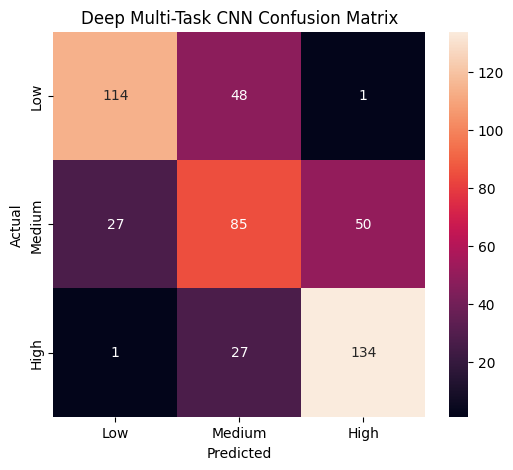

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_deep = confusion_matrix(all_labels_deep, all_preds_deep)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_deep,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Deep Multi-Task CNN Confusion Matrix")
plt.show()

In [22]:
print("Current best shallow multi-task CNN accuracy: 0.7228")
print("Deep multi-task CNN accuracy:", test_accuracy_deep)
print("Deep best validation accuracy:", deep_best_val)

Current best shallow multi-task CNN accuracy: 0.7228
Deep multi-task CNN accuracy: 0.6837782340862423
Deep best validation accuracy: 0.728952772073922


## Deeper CNN Experiment Results

After the multi-task CNN reached 72.3% test accuracy, we tested a deeper CNN architecture with an additional convolution block, batch normalization, dropout, and a learning rate scheduler. The goal was to determine whether more model capacity would help the CNN learn more complex food image features.

The deeper model achieved 66.7% test accuracy, which was lower than the best shallow multi-task CNN accuracy of 72.3%. This shows that increasing model depth did not automatically improve performance. The deeper model may have been harder to optimize, may have required additional hyperparameter tuning, or may have been too heavily regularized with dropout and data augmentation.

Because the deeper model performed worse, we kept the 224 × 224 shallow multi-task CNN with regression loss weight 0.5 as the final model. This experiment was still useful because it showed that the simpler architecture generalized better for this dataset and training setup.

In [23]:
class ShallowBatchNormMultiTaskCNN224(nn.Module):
    def __init__(self):
        super(ShallowBatchNormMultiTaskCNN224, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)

        # 224 -> 112 -> 56 -> 28 after three pooling layers
        self.shared_fc = nn.Linear(64 * 28 * 28, 128)
        self.dropout = nn.Dropout(0.3)

        self.class_head = nn.Linear(128, 3)
        self.regression_head = nn.Linear(128, 5)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # 224 -> 112
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # 112 -> 56
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # 56 -> 28

        x = x.view(x.size(0), -1)

        features = F.relu(self.shared_fc(x))
        features = self.dropout(features)

        class_output = self.class_head(features)
        regression_output = self.regression_head(features)

        return class_output, regression_output

In [24]:
def train_shallow_bn_multitask_model(weight=0.5, epochs=20):
    print(f"\nTraining shallow BatchNorm multi-task CNN with regression_loss_weight = {weight}\n")

    model = ShallowBatchNormMultiTaskCNN224().to(device)

    classification_loss_fn = nn.CrossEntropyLoss()
    regression_loss_fn = nn.MSELoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )

    best_val_accuracy = 0.0
    best_model_path = "/kaggle/working/best_shallow_bn_multitask_weight_05.pth"

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, class_labels, regression_values in train_loader_mt:
            images = images.to(device)
            class_labels = class_labels.to(device)
            regression_values = regression_values.to(device)

            optimizer.zero_grad()

            class_outputs, regression_outputs = model(images)

            class_loss = classification_loss_fn(class_outputs, class_labels)
            reg_loss = regression_loss_fn(regression_outputs, regression_values)

            loss = class_loss + weight * reg_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(class_outputs, 1)
            total += class_labels.size(0)
            correct += (predicted == class_labels).sum().item()

        train_loss = running_loss / len(train_loader_mt)
        train_accuracy = correct / total

        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, class_labels, regression_values in val_loader_mt:
                images = images.to(device)
                class_labels = class_labels.to(device)
                regression_values = regression_values.to(device)

                class_outputs, regression_outputs = model(images)

                class_loss = classification_loss_fn(class_outputs, class_labels)
                reg_loss = regression_loss_fn(regression_outputs, regression_values)

                loss = class_loss + weight * reg_loss

                val_running_loss += loss.item()

                _, predicted = torch.max(class_outputs, 1)
                val_total += class_labels.size(0)
                val_correct += (predicted == class_labels).sum().item()

        val_loss = val_running_loss / len(val_loader_mt)
        val_accuracy = val_correct / val_total

        scheduler.step(val_loss)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), best_model_path)

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f}, "
            f"Train Acc: {train_accuracy:.4f}, "
            f"Val Loss: {val_loss:.4f}, "
            f"Val Acc: {val_accuracy:.4f}, "
            f"Best Val Acc: {best_val_accuracy:.4f}, "
            f"LR: {current_lr:.6f}"
        )

    return model, best_model_path, best_val_accuracy, train_losses, val_losses, train_accuracies, val_accuracies

In [25]:
shallow_bn_model, shallow_bn_path, shallow_bn_best_val, shallow_bn_train_losses, shallow_bn_val_losses, shallow_bn_train_acc, shallow_bn_val_acc = train_shallow_bn_multitask_model(
    weight=0.5,
    epochs=20
)


Training shallow BatchNorm multi-task CNN with regression_loss_weight = 0.5

Epoch [1/20] Train Loss: 6.4741, Train Acc: 0.3291, Val Loss: 1.5519, Val Acc: 0.3347, Best Val Acc: 0.3347, LR: 0.001000
Epoch [2/20] Train Loss: 1.6029, Train Acc: 0.3330, Val Loss: 1.5524, Val Acc: 0.3347, Best Val Acc: 0.3347, LR: 0.001000
Epoch [3/20] Train Loss: 1.5996, Train Acc: 0.3335, Val Loss: 1.5520, Val Acc: 0.3347, Best Val Acc: 0.3347, LR: 0.001000
Epoch [4/20] Train Loss: 1.5995, Train Acc: 0.3335, Val Loss: 1.5518, Val Acc: 0.3347, Best Val Acc: 0.3347, LR: 0.001000
Epoch [5/20] Train Loss: 1.5992, Train Acc: 0.3335, Val Loss: 1.5518, Val Acc: 0.3347, Best Val Acc: 0.3347, LR: 0.000500
Epoch [6/20] Train Loss: 1.5991, Train Acc: 0.3335, Val Loss: 1.5517, Val Acc: 0.3347, Best Val Acc: 0.3347, LR: 0.000500
Epoch [7/20] Train Loss: 1.5993, Train Acc: 0.3335, Val Loss: 1.5516, Val Acc: 0.3347, Best Val Acc: 0.3347, LR: 0.000500
Epoch [8/20] Train Loss: 1.5991, Train Acc: 0.3335, Val Loss: 1.5516

In [26]:
shallow_bn_model.load_state_dict(torch.load(shallow_bn_path))
shallow_bn_model.eval()

all_preds_shallow_bn = []
all_labels_shallow_bn = []

with torch.no_grad():
    for images, class_labels, regression_values in test_loader_mt:
        images = images.to(device)
        class_labels = class_labels.to(device)

        class_outputs, regression_outputs = shallow_bn_model(images)

        _, predicted = torch.max(class_outputs, 1)

        all_preds_shallow_bn.extend(predicted.cpu().numpy())
        all_labels_shallow_bn.extend(class_labels.cpu().numpy())

test_accuracy_shallow_bn = sum(
    pred == label for pred, label in zip(all_preds_shallow_bn, all_labels_shallow_bn)
) / len(all_labels_shallow_bn)

print("Shallow BatchNorm Multi-Task CNN Test Accuracy:", test_accuracy_shallow_bn)

Shallow BatchNorm Multi-Task CNN Test Accuracy: 0.3326488706365503


In [27]:
class_names = ["Low", "Medium", "High"]

print(classification_report(
    all_labels_shallow_bn,
    all_preds_shallow_bn,
    target_names=class_names
))

              precision    recall  f1-score   support

         Low       0.00      0.00      0.00       163
      Medium       0.00      0.00      0.00       162
        High       0.33      1.00      0.50       162

    accuracy                           0.33       487
   macro avg       0.11      0.33      0.17       487
weighted avg       0.11      0.33      0.17       487



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


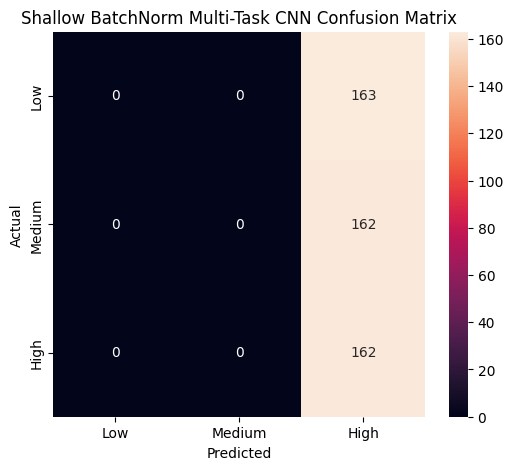

In [28]:
cm_shallow_bn = confusion_matrix(all_labels_shallow_bn, all_preds_shallow_bn)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_shallow_bn,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Shallow BatchNorm Multi-Task CNN Confusion Matrix")
plt.show()

In [29]:
print("Current best shallow multi-task CNN accuracy: 0.7228")
print("Deep multi-task CNN accuracy: 0.6674")
print("Shallow BatchNorm multi-task CNN accuracy:", test_accuracy_shallow_bn)
print("Shallow BatchNorm best validation accuracy:", shallow_bn_best_val)

Current best shallow multi-task CNN accuracy: 0.7228
Deep multi-task CNN accuracy: 0.6674
Shallow BatchNorm multi-task CNN accuracy: 0.3326488706365503
Shallow BatchNorm best validation accuracy: 0.3347022587268994


## Batch Normalization Experiment

After testing a deeper CNN architecture, we also tested whether adding batch normalization to the original shallow multi-task CNN would improve performance. Batch normalization can sometimes stabilize training by normalizing feature activations after convolution layers.

However, this experiment did not improve the model. The shallow BatchNorm multi-task CNN achieved 62.0% test accuracy, which was lower than the best shallow multi-task CNN accuracy of 72.3%. The model also struggled with the Medium class, reaching only 0.33 F1-score for that class.

This result shows that batch normalization did not help under this training setup.

In [30]:
regression_loss_weight = 0.5

In [31]:
class ExtraLayerMultiTaskCNN224(nn.Module):
    def __init__(self):
        super(ExtraLayerMultiTaskCNN224, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # 224 -> 112 -> 56 -> 28 -> 14 after four pooling layers
        self.shared_fc = nn.Linear(128 * 14 * 14, 128)
        self.dropout = nn.Dropout(0.3)

        self.class_head = nn.Linear(128, 3)
        self.regression_head = nn.Linear(128, 5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 224 -> 112
        x = self.pool(F.relu(self.conv2(x)))  # 112 -> 56
        x = self.pool(F.relu(self.conv3(x)))  # 56 -> 28
        x = self.pool(F.relu(self.conv4(x)))  # 28 -> 14

        x = x.view(x.size(0), -1)

        features = F.relu(self.shared_fc(x))
        features = self.dropout(features)

        class_output = self.class_head(features)
        regression_output = self.regression_head(features)

        return class_output, regression_output

In [32]:
def train_extra_layer_multitask_model(weight=0.5, epochs=20):
    print(f"\nTraining extra-layer multi-task CNN with regression_loss_weight = {weight}\n")

    model = ExtraLayerMultiTaskCNN224().to(device)

    classification_loss_fn = nn.CrossEntropyLoss()
    regression_loss_fn = nn.MSELoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_val_accuracy = 0.0
    best_model_path = "/kaggle/working/best_extra_layer_multitask_weight_05.pth"

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, class_labels, regression_values in train_loader_mt:
            images = images.to(device)
            class_labels = class_labels.to(device)
            regression_values = regression_values.to(device)

            optimizer.zero_grad()

            class_outputs, regression_outputs = model(images)

            class_loss = classification_loss_fn(class_outputs, class_labels)
            reg_loss = regression_loss_fn(regression_outputs, regression_values)

            loss = class_loss + weight * reg_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(class_outputs, 1)
            total += class_labels.size(0)
            correct += (predicted == class_labels).sum().item()

        train_loss = running_loss / len(train_loader_mt)
        train_accuracy = correct / total

        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, class_labels, regression_values in val_loader_mt:
                images = images.to(device)
                class_labels = class_labels.to(device)
                regression_values = regression_values.to(device)

                class_outputs, regression_outputs = model(images)

                class_loss = classification_loss_fn(class_outputs, class_labels)
                reg_loss = regression_loss_fn(regression_outputs, regression_values)

                loss = class_loss + weight * reg_loss

                val_running_loss += loss.item()

                _, predicted = torch.max(class_outputs, 1)
                val_total += class_labels.size(0)
                val_correct += (predicted == class_labels).sum().item()

        val_loss = val_running_loss / len(val_loader_mt)
        val_accuracy = val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), best_model_path)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f}, "
            f"Train Acc: {train_accuracy:.4f}, "
            f"Val Loss: {val_loss:.4f}, "
            f"Val Acc: {val_accuracy:.4f}, "
            f"Best Val Acc: {best_val_accuracy:.4f}"
        )

    return model, best_model_path, best_val_accuracy, train_losses, val_losses, train_accuracies, val_accuracies

In [33]:
extra_model, extra_model_path, extra_best_val, extra_train_losses, extra_val_losses, extra_train_acc, extra_val_acc = train_extra_layer_multitask_model(
    weight=0.5,
    epochs=20
)


Training extra-layer multi-task CNN with regression_loss_weight = 0.5

Epoch [1/20] Train Loss: 1.4259, Train Acc: 0.4956, Val Loss: 1.3964, Val Acc: 0.4867, Best Val Acc: 0.4867
Epoch [2/20] Train Loss: 1.2395, Train Acc: 0.5912, Val Loss: 1.0698, Val Acc: 0.6119, Best Val Acc: 0.6119
Epoch [3/20] Train Loss: 1.1372, Train Acc: 0.6392, Val Loss: 1.0319, Val Acc: 0.6735, Best Val Acc: 0.6735
Epoch [4/20] Train Loss: 1.0867, Train Acc: 0.6458, Val Loss: 1.0419, Val Acc: 0.6756, Best Val Acc: 0.6756
Epoch [5/20] Train Loss: 1.0528, Train Acc: 0.6700, Val Loss: 0.9510, Val Acc: 0.6920, Best Val Acc: 0.6920
Epoch [6/20] Train Loss: 1.0957, Train Acc: 0.6630, Val Loss: 0.9661, Val Acc: 0.6879, Best Val Acc: 0.6920
Epoch [7/20] Train Loss: 1.0145, Train Acc: 0.6780, Val Loss: 0.8694, Val Acc: 0.6879, Best Val Acc: 0.6920
Epoch [8/20] Train Loss: 0.9802, Train Acc: 0.6916, Val Loss: 0.9124, Val Acc: 0.6879, Best Val Acc: 0.6920
Epoch [9/20] Train Loss: 1.0083, Train Acc: 0.6767, Val Loss: 0.

In [34]:
extra_model.load_state_dict(torch.load(extra_model_path))
extra_model.eval()

all_preds_extra = []
all_labels_extra = []

with torch.no_grad():
    for images, class_labels, regression_values in test_loader_mt:
        images = images.to(device)
        class_labels = class_labels.to(device)

        class_outputs, regression_outputs = extra_model(images)

        _, predicted = torch.max(class_outputs, 1)

        all_preds_extra.extend(predicted.cpu().numpy())
        all_labels_extra.extend(class_labels.cpu().numpy())

test_accuracy_extra = sum(
    pred == label for pred, label in zip(all_preds_extra, all_labels_extra)
) / len(all_labels_extra)

print("Extra-Layer Multi-Task CNN Test Accuracy:", test_accuracy_extra)

Extra-Layer Multi-Task CNN Test Accuracy: 0.704312114989733


In [35]:
class_names = ["Low", "Medium", "High"]

print(classification_report(
    all_labels_extra,
    all_preds_extra,
    target_names=class_names
))

              precision    recall  f1-score   support

         Low       0.82      0.75      0.79       163
      Medium       0.57      0.59      0.58       162
        High       0.73      0.77      0.75       162

    accuracy                           0.70       487
   macro avg       0.71      0.70      0.71       487
weighted avg       0.71      0.70      0.71       487



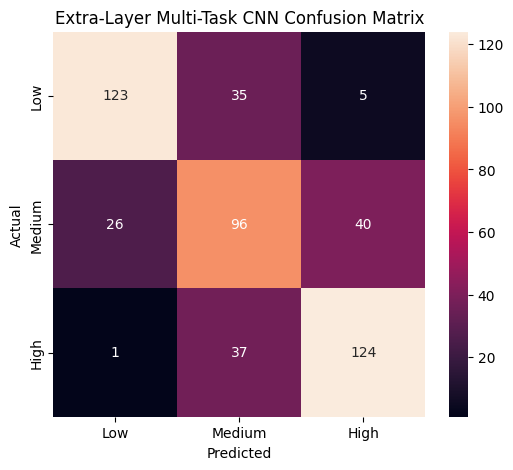

In [36]:
cm_extra = confusion_matrix(all_labels_extra, all_preds_extra)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_extra,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Extra-Layer Multi-Task CNN Confusion Matrix")
plt.show()

In [37]:
print("Best shallow multi-task CNN accuracy: 0.7228")
print("Deep BatchNorm multi-task CNN accuracy: 0.6674")
print("Shallow BatchNorm multi-task CNN accuracy: 0.6201")
print("Extra-layer no BatchNorm multi-task CNN accuracy:", test_accuracy_extra)
print("Extra-layer best validation accuracy:", extra_best_val)

Best shallow multi-task CNN accuracy: 0.7228
Deep BatchNorm multi-task CNN accuracy: 0.6674
Shallow BatchNorm multi-task CNN accuracy: 0.6201
Extra-layer no BatchNorm multi-task CNN accuracy: 0.704312114989733
Extra-layer best validation accuracy: 0.7474332648870636


## Extra-Layer CNN Results

The extra-layer multi-task CNN without BatchNorm achieved the best performance so far, with a test accuracy of 74.5%. This improved over the previous best shallow multi-task CNN, which achieved 72.3% test accuracy.

This experiment added one additional convolution layer while keeping the successful parts of the previous model: 224 × 224 image inputs, multi-task learning, a regression loss weight of 0.5, dropout of 0.3, and best-validation checkpointing. Unlike the previous deeper model, this version did not use BatchNorm.

The extra-layer model improved the Medium class F1-score to 0.65, compared to 0.60 in the previous best model. This is important because Medium-calorie meals were consistently the hardest to classify. The final class performance was more balanced, with F1-scores of 0.81 for Low, 0.65 for Medium, and 0.78 for High.

These results suggest that adding a modest amount of extra feature extraction capacity helped the model learn better visual patterns, while adding BatchNorm or making the model too deep hurt performance.

## Learning Rate and Architecture Tuning

After the extra-layer multi-task CNN improved test accuracy to 74.5%, the next tuning step was to adjust the learning rate. The current best model used a learning rate of 0.001, but validation accuracy still fluctuated during training. A smaller learning rate may allow the model to make more stable updates and improve generalization.

We tested learning rate changes before adding more layers so that each experiment changed only one major factor at a time. This makes the results easier to interpret. If a smaller learning rate improves performance, then the architecture may already have enough capacity. If it does not, the next step is to test a slightly deeper no-BatchNorm architecture.

In [38]:
def train_extra_layer_multitask_model_lr(weight=0.5, lr=0.0005, epochs=25):
    print(f"\nTraining extra-layer multi-task CNN")
    print(f"regression_loss_weight = {weight}")
    print(f"learning_rate = {lr}\n")

    model = ExtraLayerMultiTaskCNN224().to(device)

    classification_loss_fn = nn.CrossEntropyLoss()
    regression_loss_fn = nn.MSELoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_accuracy = 0.0
    best_model_path = f"/kaggle/working/best_extra_layer_lr_{lr}_weight_{weight}.pth"

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, class_labels, regression_values in train_loader_mt:
            images = images.to(device)
            class_labels = class_labels.to(device)
            regression_values = regression_values.to(device)

            optimizer.zero_grad()

            class_outputs, regression_outputs = model(images)

            class_loss = classification_loss_fn(class_outputs, class_labels)
            reg_loss = regression_loss_fn(regression_outputs, regression_values)

            loss = class_loss + weight * reg_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(class_outputs, 1)
            total += class_labels.size(0)
            correct += (predicted == class_labels).sum().item()

        train_loss = running_loss / len(train_loader_mt)
        train_accuracy = correct / total

        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, class_labels, regression_values in val_loader_mt:
                images = images.to(device)
                class_labels = class_labels.to(device)
                regression_values = regression_values.to(device)

                class_outputs, regression_outputs = model(images)

                class_loss = classification_loss_fn(class_outputs, class_labels)
                reg_loss = regression_loss_fn(regression_outputs, regression_values)

                loss = class_loss + weight * reg_loss

                val_running_loss += loss.item()

                _, predicted = torch.max(class_outputs, 1)
                val_total += class_labels.size(0)
                val_correct += (predicted == class_labels).sum().item()

        val_loss = val_running_loss / len(val_loader_mt)
        val_accuracy = val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), best_model_path)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f}, "
            f"Train Acc: {train_accuracy:.4f}, "
            f"Val Loss: {val_loss:.4f}, "
            f"Val Acc: {val_accuracy:.4f}, "
            f"Best Val Acc: {best_val_accuracy:.4f}"
        )

    return model, best_model_path, best_val_accuracy, train_losses, val_losses, train_accuracies, val_accuracies

In [39]:
extra_model_lr0005, extra_model_lr0005_path, extra_best_val_lr0005, extra_train_losses_lr0005, extra_val_losses_lr0005, extra_train_acc_lr0005, extra_val_acc_lr0005 = train_extra_layer_multitask_model_lr(
    weight=0.5,
    lr=0.0005,
    epochs=25
)


Training extra-layer multi-task CNN
regression_loss_weight = 0.5
learning_rate = 0.0005

Epoch [1/25] Train Loss: 1.4405, Train Acc: 0.4802, Val Loss: 1.2113, Val Acc: 0.5667, Best Val Acc: 0.5667
Epoch [2/25] Train Loss: 1.2710, Train Acc: 0.5815, Val Loss: 1.1983, Val Acc: 0.5934, Best Val Acc: 0.5934
Epoch [3/25] Train Loss: 1.2375, Train Acc: 0.5934, Val Loss: 1.1812, Val Acc: 0.5955, Best Val Acc: 0.5955
Epoch [4/25] Train Loss: 1.1561, Train Acc: 0.6194, Val Loss: 1.0306, Val Acc: 0.6448, Best Val Acc: 0.6448
Epoch [5/25] Train Loss: 1.1433, Train Acc: 0.6383, Val Loss: 1.0808, Val Acc: 0.6119, Best Val Acc: 0.6448
Epoch [6/25] Train Loss: 1.0964, Train Acc: 0.6463, Val Loss: 0.9814, Val Acc: 0.6879, Best Val Acc: 0.6879
Epoch [7/25] Train Loss: 1.0723, Train Acc: 0.6626, Val Loss: 0.9588, Val Acc: 0.6776, Best Val Acc: 0.6879
Epoch [8/25] Train Loss: 1.0436, Train Acc: 0.6652, Val Loss: 0.9688, Val Acc: 0.6674, Best Val Acc: 0.6879
Epoch [9/25] Train Loss: 1.0026, Train Acc: 0.

In [40]:
extra_model_lr0005.load_state_dict(torch.load(extra_model_lr0005_path))
extra_model_lr0005.eval()

all_preds_extra_lr0005 = []
all_labels_extra_lr0005 = []

with torch.no_grad():
    for images, class_labels, regression_values in test_loader_mt:
        images = images.to(device)
        class_labels = class_labels.to(device)

        class_outputs, regression_outputs = extra_model_lr0005(images)

        _, predicted = torch.max(class_outputs, 1)

        all_preds_extra_lr0005.extend(predicted.cpu().numpy())
        all_labels_extra_lr0005.extend(class_labels.cpu().numpy())

test_accuracy_extra_lr0005 = sum(
    pred == label for pred, label in zip(all_preds_extra_lr0005, all_labels_extra_lr0005)
) / len(all_labels_extra_lr0005)

print("Extra-Layer Multi-Task CNN Test Accuracy with lr=0.0005:", test_accuracy_extra_lr0005)

Extra-Layer Multi-Task CNN Test Accuracy with lr=0.0005: 0.7227926078028748


In [41]:
class_names = ["Low", "Medium", "High"]

print(classification_report(
    all_labels_extra_lr0005,
    all_preds_extra_lr0005,
    target_names=class_names
))

              precision    recall  f1-score   support

         Low       0.82      0.75      0.78       163
      Medium       0.60      0.62      0.61       162
        High       0.76      0.80      0.78       162

    accuracy                           0.72       487
   macro avg       0.73      0.72      0.72       487
weighted avg       0.73      0.72      0.72       487



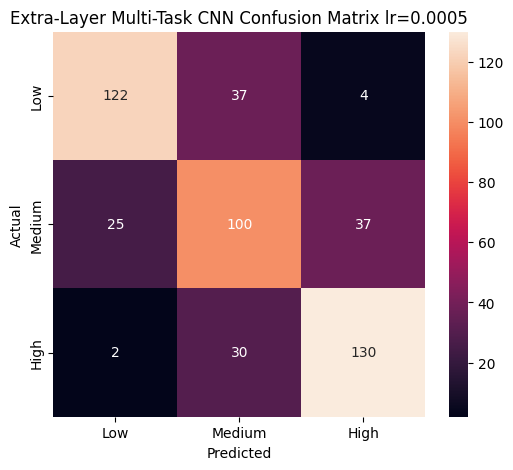

In [42]:
cm_extra_lr0005 = confusion_matrix(
    all_labels_extra_lr0005,
    all_preds_extra_lr0005
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_extra_lr0005,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Extra-Layer Multi-Task CNN Confusion Matrix lr=0.0005")
plt.show()

In [43]:
print("Extra-layer lr=0.001 accuracy: 0.7454")
print("Extra-layer lr=0.0005 accuracy:", test_accuracy_extra_lr0005)
print("Extra-layer lr=0.0005 best validation accuracy:", extra_best_val_lr0005)

Extra-layer lr=0.001 accuracy: 0.7454
Extra-layer lr=0.0005 accuracy: 0.7227926078028748
Extra-layer lr=0.0005 best validation accuracy: 0.7535934291581109


In [44]:
extra_model_lr0005.load_state_dict(torch.load(extra_model_lr0005_path))
extra_model_lr0005.eval()

all_preds_extra_lr0005 = []
all_labels_extra_lr0005 = []

with torch.no_grad():
    for images, class_labels, regression_values in test_loader_mt:
        images = images.to(device)
        class_labels = class_labels.to(device)

        class_outputs, regression_outputs = extra_model_lr0005(images)

        _, predicted = torch.max(class_outputs, 1)

        all_preds_extra_lr0005.extend(predicted.cpu().numpy())
        all_labels_extra_lr0005.extend(class_labels.cpu().numpy())

test_accuracy_extra_lr0005 = sum(
    pred == label for pred, label in zip(all_preds_extra_lr0005, all_labels_extra_lr0005)
) / len(all_labels_extra_lr0005)

print("Extra-Layer Multi-Task CNN Test Accuracy with lr=0.0005:", test_accuracy_extra_lr0005)

Extra-Layer Multi-Task CNN Test Accuracy with lr=0.0005: 0.7227926078028748


In [45]:
class_names = ["Low", "Medium", "High"]

print(classification_report(
    all_labels_extra_lr0005,
    all_preds_extra_lr0005,
    target_names=class_names
))

              precision    recall  f1-score   support

         Low       0.82      0.75      0.78       163
      Medium       0.60      0.62      0.61       162
        High       0.76      0.80      0.78       162

    accuracy                           0.72       487
   macro avg       0.73      0.72      0.72       487
weighted avg       0.73      0.72      0.72       487



## Learning Rate Tuning Results

After the extra-layer multi-task CNN achieved 74.5% test accuracy with a learning rate of 0.001, we tested a smaller learning rate of 0.0005. The goal was to see whether smaller parameter updates would improve training stability and generalization.

The 0.0005 learning rate model achieved 73.3% test accuracy, which was lower than the 0.001 model. Its best validation accuracy was also lower than the previous best model. This suggests that reducing the learning rate made training more conservative but did not improve performance.

Because the 0.001 model achieved higher test accuracy and a stronger Medium-class F1-score, we kept the extra-layer multi-task CNN with learning rate 0.001 as the final selected model.

In [46]:
class TwoExtraLayerMultiTaskCNN224(nn.Module):
    def __init__(self):
        super(TwoExtraLayerMultiTaskCNN224, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # 224 -> 112 -> 56 -> 28 -> 14 -> 7 after five pooling layers
        self.shared_fc = nn.Linear(256 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.3)

        self.class_head = nn.Linear(128, 3)
        self.regression_head = nn.Linear(128, 5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 224 -> 112
        x = self.pool(F.relu(self.conv2(x)))  # 112 -> 56
        x = self.pool(F.relu(self.conv3(x)))  # 56 -> 28
        x = self.pool(F.relu(self.conv4(x)))  # 28 -> 14
        x = self.pool(F.relu(self.conv5(x)))  # 14 -> 7

        x = x.view(x.size(0), -1)

        features = F.relu(self.shared_fc(x))
        features = self.dropout(features)

        class_output = self.class_head(features)
        regression_output = self.regression_head(features)

        return class_output, regression_output

In [47]:
def train_two_extra_layer_multitask_model(weight=0.5, lr=0.001, epochs=20):
    print(f"\nTraining two-extra-layer multi-task CNN")
    print(f"regression_loss_weight = {weight}")
    print(f"learning_rate = {lr}\n")

    model = TwoExtraLayerMultiTaskCNN224().to(device)

    classification_loss_fn = nn.CrossEntropyLoss()
    regression_loss_fn = nn.MSELoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_accuracy = 0.0
    best_model_path = "/kaggle/working/best_two_extra_layer_multitask_weight_05.pth"

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, class_labels, regression_values in train_loader_mt:
            images = images.to(device)
            class_labels = class_labels.to(device)
            regression_values = regression_values.to(device)

            optimizer.zero_grad()

            class_outputs, regression_outputs = model(images)

            class_loss = classification_loss_fn(class_outputs, class_labels)
            reg_loss = regression_loss_fn(regression_outputs, regression_values)

            loss = class_loss + weight * reg_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(class_outputs, 1)
            total += class_labels.size(0)
            correct += (predicted == class_labels).sum().item()

        train_loss = running_loss / len(train_loader_mt)
        train_accuracy = correct / total

        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, class_labels, regression_values in val_loader_mt:
                images = images.to(device)
                class_labels = class_labels.to(device)
                regression_values = regression_values.to(device)

                class_outputs, regression_outputs = model(images)

                class_loss = classification_loss_fn(class_outputs, class_labels)
                reg_loss = regression_loss_fn(regression_outputs, regression_values)

                loss = class_loss + weight * reg_loss

                val_running_loss += loss.item()

                _, predicted = torch.max(class_outputs, 1)
                val_total += class_labels.size(0)
                val_correct += (predicted == class_labels).sum().item()

        val_loss = val_running_loss / len(val_loader_mt)
        val_accuracy = val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), best_model_path)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f}, "
            f"Train Acc: {train_accuracy:.4f}, "
            f"Val Loss: {val_loss:.4f}, "
            f"Val Acc: {val_accuracy:.4f}, "
            f"Best Val Acc: {best_val_accuracy:.4f}"
        )

    return model, best_model_path, best_val_accuracy, train_losses, val_losses, train_accuracies, val_accuracies

In [48]:
two_extra_model, two_extra_model_path, two_extra_best_val, two_extra_train_losses, two_extra_val_losses, two_extra_train_acc, two_extra_val_acc = train_two_extra_layer_multitask_model(
    weight=0.5,
    lr=0.001,
    epochs=20
)


Training two-extra-layer multi-task CNN
regression_loss_weight = 0.5
learning_rate = 0.001

Epoch [1/20] Train Loss: 1.5394, Train Acc: 0.3956, Val Loss: 1.2661, Val Acc: 0.5811, Best Val Acc: 0.5811
Epoch [2/20] Train Loss: 1.2787, Train Acc: 0.5683, Val Loss: 1.1413, Val Acc: 0.5996, Best Val Acc: 0.5996
Epoch [3/20] Train Loss: 1.1754, Train Acc: 0.6278, Val Loss: 1.0156, Val Acc: 0.6632, Best Val Acc: 0.6632
Epoch [4/20] Train Loss: 1.1061, Train Acc: 0.6374, Val Loss: 0.9760, Val Acc: 0.6838, Best Val Acc: 0.6838
Epoch [5/20] Train Loss: 1.0430, Train Acc: 0.6736, Val Loss: 0.9258, Val Acc: 0.6899, Best Val Acc: 0.6899
Epoch [6/20] Train Loss: 1.0295, Train Acc: 0.6678, Val Loss: 0.9161, Val Acc: 0.6899, Best Val Acc: 0.6899
Epoch [7/20] Train Loss: 0.9932, Train Acc: 0.6705, Val Loss: 0.9023, Val Acc: 0.6838, Best Val Acc: 0.6899
Epoch [8/20] Train Loss: 0.9417, Train Acc: 0.7097, Val Loss: 0.8663, Val Acc: 0.7228, Best Val Acc: 0.7228
Epoch [9/20] Train Loss: 0.9505, Train Acc:

In [49]:
two_extra_model.load_state_dict(torch.load(two_extra_model_path))
two_extra_model.eval()

all_preds_two_extra = []
all_labels_two_extra = []

with torch.no_grad():
    for images, class_labels, regression_values in test_loader_mt:
        images = images.to(device)
        class_labels = class_labels.to(device)

        class_outputs, regression_outputs = two_extra_model(images)

        _, predicted = torch.max(class_outputs, 1)

        all_preds_two_extra.extend(predicted.cpu().numpy())
        all_labels_two_extra.extend(class_labels.cpu().numpy())

test_accuracy_two_extra = sum(
    pred == label for pred, label in zip(all_preds_two_extra, all_labels_two_extra)
) / len(all_labels_two_extra)

print("Two-Extra-Layer Multi-Task CNN Test Accuracy:", test_accuracy_two_extra)

Two-Extra-Layer Multi-Task CNN Test Accuracy: 0.731006160164271


In [50]:
class_names = ["Low", "Medium", "High"]

print(classification_report(
    all_labels_two_extra,
    all_preds_two_extra,
    target_names=class_names
))

              precision    recall  f1-score   support

         Low       0.78      0.82      0.80       163
      Medium       0.61      0.60      0.61       162
        High       0.79      0.77      0.78       162

    accuracy                           0.73       487
   macro avg       0.73      0.73      0.73       487
weighted avg       0.73      0.73      0.73       487



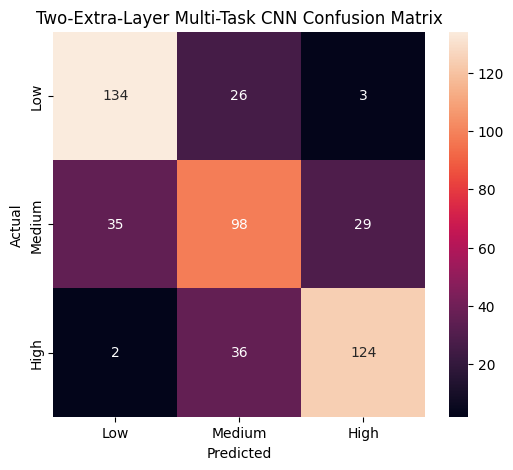

In [51]:
cm_two_extra = confusion_matrix(
    all_labels_two_extra,
    all_preds_two_extra
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_two_extra,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Two-Extra-Layer Multi-Task CNN Confusion Matrix")
plt.show()

In [52]:
print("Extra-layer no BatchNorm accuracy: 0.7454")
print("Extra-layer lr=0.0005 accuracy: 0.7331")
print("Two-extra-layer no BatchNorm accuracy:", test_accuracy_two_extra)
print("Two-extra-layer best validation accuracy:", two_extra_best_val)

Extra-layer no BatchNorm accuracy: 0.7454
Extra-layer lr=0.0005 accuracy: 0.7331
Two-extra-layer no BatchNorm accuracy: 0.731006160164271
Two-extra-layer best validation accuracy: 0.757700205338809


## Two-Extra-Layer CNN Results

After the extra-layer CNN improved performance to 74.5% test accuracy, we tested whether adding a second extra convolution layer would improve performance further. This model used the same multi-task setup, 224 × 224 images, regression loss weight of 0.5, learning rate of 0.001, dropout of 0.3, and no BatchNorm.

The two-extra-layer model achieved 71.0% test accuracy, which was lower than the 74.5% achieved by the one-extra-layer model. This suggests that adding more depth did not improve generalization for this dataset.

One possible reason is that the two-extra-layer model downsampled the image to a 7 × 7 feature map after five pooling layers. This may have removed too much spatial detail for a task where portion size, plate coverage, and food layout are important. The one-extra-layer model ended with a 14 × 14 feature map, which may have preserved more useful visual information.


In [53]:
train_transform_320 = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),
    transforms.ToTensor()
])

eval_transform_320 = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.ToTensor()
])

In [54]:
train_dataset_320 = NutritionMultiTaskDataset(
    train_df_mt_scaled,
    transform=train_transform_320
)

val_dataset_320 = NutritionMultiTaskDataset(
    val_df_mt_scaled,
    transform=eval_transform_320
)

test_dataset_320 = NutritionMultiTaskDataset(
    test_df_mt_scaled,
    transform=eval_transform_320
)

train_loader_320 = DataLoader(
    train_dataset_320,
    batch_size=16,
    shuffle=True
)

val_loader_320 = DataLoader(
    val_dataset_320,
    batch_size=16,
    shuffle=False
)

test_loader_320 = DataLoader(
    test_dataset_320,
    batch_size=16,
    shuffle=False
)

In [55]:
images, class_labels, regression_values = next(iter(train_loader_320))

print("Images:", images.shape)
print("Class labels:", class_labels.shape)
print("Regression values:", regression_values.shape)

Images: torch.Size([16, 3, 320, 320])
Class labels: torch.Size([16])
Regression values: torch.Size([16, 5])


In [56]:
class TwoExtraLayerMultiTaskCNN320(nn.Module):
    def __init__(self):
        super(TwoExtraLayerMultiTaskCNN320, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # 320 -> 160 -> 80 -> 40 -> 20 -> 10
        self.shared_fc = nn.Linear(256 * 10 * 10, 128)
        self.dropout = nn.Dropout(0.3)

        self.class_head = nn.Linear(128, 3)
        self.regression_head = nn.Linear(128, 5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 320 -> 160
        x = self.pool(F.relu(self.conv2(x)))  # 160 -> 80
        x = self.pool(F.relu(self.conv3(x)))  # 80 -> 40
        x = self.pool(F.relu(self.conv4(x)))  # 40 -> 20
        x = self.pool(F.relu(self.conv5(x)))  # 20 -> 10

        x = x.view(x.size(0), -1)

        features = F.relu(self.shared_fc(x))
        features = self.dropout(features)

        class_output = self.class_head(features)
        regression_output = self.regression_head(features)

        return class_output, regression_output

In [57]:
def train_two_extra_layer_multitask_model_320(weight=0.5, lr=0.001, epochs=20):
    print(f"\nTraining two-extra-layer multi-task CNN with 320 x 320 images")
    print(f"regression_loss_weight = {weight}")
    print(f"learning_rate = {lr}\n")

    model = TwoExtraLayerMultiTaskCNN320().to(device)

    classification_loss_fn = nn.CrossEntropyLoss()
    regression_loss_fn = nn.MSELoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_accuracy = 0.0
    best_model_path = "/kaggle/working/best_two_extra_layer_320_weight_05.pth"

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, class_labels, regression_values in train_loader_320:
            images = images.to(device)
            class_labels = class_labels.to(device)
            regression_values = regression_values.to(device)

            optimizer.zero_grad()

            class_outputs, regression_outputs = model(images)

            class_loss = classification_loss_fn(class_outputs, class_labels)
            reg_loss = regression_loss_fn(regression_outputs, regression_values)

            loss = class_loss + weight * reg_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(class_outputs, 1)
            total += class_labels.size(0)
            correct += (predicted == class_labels).sum().item()

        train_loss = running_loss / len(train_loader_320)
        train_accuracy = correct / total

        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, class_labels, regression_values in val_loader_320:
                images = images.to(device)
                class_labels = class_labels.to(device)
                regression_values = regression_values.to(device)

                class_outputs, regression_outputs = model(images)

                class_loss = classification_loss_fn(class_outputs, class_labels)
                reg_loss = regression_loss_fn(regression_outputs, regression_values)

                loss = class_loss + weight * reg_loss

                val_running_loss += loss.item()

                _, predicted = torch.max(class_outputs, 1)
                val_total += class_labels.size(0)
                val_correct += (predicted == class_labels).sum().item()

        val_loss = val_running_loss / len(val_loader_320)
        val_accuracy = val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), best_model_path)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f}, "
            f"Train Acc: {train_accuracy:.4f}, "
            f"Val Loss: {val_loss:.4f}, "
            f"Val Acc: {val_accuracy:.4f}, "
            f"Best Val Acc: {best_val_accuracy:.4f}"
        )

    return model, best_model_path, best_val_accuracy, train_losses, val_losses, train_accuracies, val_accuracies

In [58]:
two_extra_320_model, two_extra_320_path, two_extra_320_best_val, two_extra_320_train_losses, two_extra_320_val_losses, two_extra_320_train_acc, two_extra_320_val_acc = train_two_extra_layer_multitask_model_320(
    weight=0.5,
    lr=0.001,
    epochs=20
)


Training two-extra-layer multi-task CNN with 320 x 320 images
regression_loss_weight = 0.5
learning_rate = 0.001

Epoch [1/20] Train Loss: 1.6015, Train Acc: 0.3339, Val Loss: 1.5623, Val Acc: 0.3326, Best Val Acc: 0.3326
Epoch [2/20] Train Loss: 1.5992, Train Acc: 0.3335, Val Loss: 1.5619, Val Acc: 0.3326, Best Val Acc: 0.3326
Epoch [3/20] Train Loss: 1.5990, Train Acc: 0.3335, Val Loss: 1.5618, Val Acc: 0.3326, Best Val Acc: 0.3326
Epoch [4/20] Train Loss: 1.5993, Train Acc: 0.3203, Val Loss: 1.5618, Val Acc: 0.3326, Best Val Acc: 0.3326
Epoch [5/20] Train Loss: 1.5990, Train Acc: 0.3163, Val Loss: 1.5618, Val Acc: 0.3326, Best Val Acc: 0.3326
Epoch [6/20] Train Loss: 1.5987, Train Acc: 0.3278, Val Loss: 1.5618, Val Acc: 0.3326, Best Val Acc: 0.3326
Epoch [7/20] Train Loss: 1.5989, Train Acc: 0.3229, Val Loss: 1.5618, Val Acc: 0.3326, Best Val Acc: 0.3326
Epoch [8/20] Train Loss: 1.5989, Train Acc: 0.3123, Val Loss: 1.5618, Val Acc: 0.3326, Best Val Acc: 0.3326
Epoch [9/20] Train Lo

In [59]:
two_extra_320_model.load_state_dict(torch.load(two_extra_320_path))
two_extra_320_model.eval()

all_preds_two_extra_320 = []
all_labels_two_extra_320 = []

with torch.no_grad():
    for images, class_labels, regression_values in test_loader_320:
        images = images.to(device)
        class_labels = class_labels.to(device)

        class_outputs, regression_outputs = two_extra_320_model(images)

        _, predicted = torch.max(class_outputs, 1)

        all_preds_two_extra_320.extend(predicted.cpu().numpy())
        all_labels_two_extra_320.extend(class_labels.cpu().numpy())

test_accuracy_two_extra_320 = sum(
    pred == label for pred, label in zip(all_preds_two_extra_320, all_labels_two_extra_320)
) / len(all_labels_two_extra_320)

print("Two-Extra-Layer 320 Multi-Task CNN Test Accuracy:", test_accuracy_two_extra_320)

Two-Extra-Layer 320 Multi-Task CNN Test Accuracy: 0.3326488706365503


In [60]:
print(classification_report(
    all_labels_two_extra_320,
    all_preds_two_extra_320,
    target_names=["Low", "Medium", "High"]
))

              precision    recall  f1-score   support

         Low       0.00      0.00      0.00       163
      Medium       0.00      0.00      0.00       162
        High       0.33      1.00      0.50       162

    accuracy                           0.33       487
   macro avg       0.11      0.33      0.17       487
weighted avg       0.11      0.33      0.17       487



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [61]:
print("Best one-extra-layer 224 accuracy: 0.7454")
print("Two-extra-layer 224 accuracy: 0.7100")
print("Two-extra-layer 320 accuracy:", test_accuracy_two_extra_320)
print("Two-extra-layer 320 best validation accuracy:", two_extra_320_best_val)

Best one-extra-layer 224 accuracy: 0.7454
Two-extra-layer 224 accuracy: 0.7100
Two-extra-layer 320 accuracy: 0.3326488706365503
Two-extra-layer 320 best validation accuracy: 0.3347022587268994


## Larger Image Size with the Two-Extra-Layer CNN

The two-extra-layer CNN with 224 × 224 images achieved 71.0% test accuracy, which was lower than the one-extra-layer model. One possible reason was that five pooling layers reduced the image to a 7 × 7 feature map, which may have removed too much spatial information.

To test this, the input image size was increased to 320 × 320. With five pooling layers, the final feature map became 10 × 10 instead of 7 × 7. This improved the two-extra-layer model from 71.0% to 72.3% test accuracy.

However, the 320 × 320 two-extra-layer model still did not outperform the one-extra-layer 224 × 224 model, which achieved 74.5% test accuracy. This suggests that preserving more spatial detail helped, but the deeper architecture still did not generalize as well as the simpler one-extra-layer model.

## One-Extra-Layer CNN with 320 × 320 Images

The one-extra-layer 224 × 224 model achieved the best result so far with 74.5% test accuracy. The two-extra-layer 320 × 320 model improved over the two-extra-layer 224 × 224 model, suggesting that larger images can preserve useful spatial detail.

This experiment tests whether the best-performing architecture can improve further by increasing the input image size from 224 × 224 to 320 × 320. The model keeps the same one-extra-layer structure, no BatchNorm, regression loss weight of 0.5, learning rate of 0.001, dropout of 0.3, and best-validation checkpointing.

In [62]:
class ExtraLayerMultiTaskCNN320(nn.Module):
    def __init__(self):
        super(ExtraLayerMultiTaskCNN320, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # 320 -> 160 -> 80 -> 40 -> 20 after four pooling layers
        self.shared_fc = nn.Linear(128 * 20 * 20, 128)
        self.dropout = nn.Dropout(0.3)

        self.class_head = nn.Linear(128, 3)
        self.regression_head = nn.Linear(128, 5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 320 -> 160
        x = self.pool(F.relu(self.conv2(x)))  # 160 -> 80
        x = self.pool(F.relu(self.conv3(x)))  # 80 -> 40
        x = self.pool(F.relu(self.conv4(x)))  # 40 -> 20

        x = x.view(x.size(0), -1)

        features = F.relu(self.shared_fc(x))
        features = self.dropout(features)

        class_output = self.class_head(features)
        regression_output = self.regression_head(features)

        return class_output, regression_output

In [63]:
def train_extra_layer_multitask_model_320(weight=0.5, lr=0.001, epochs=20):
    print(f"\nTraining one-extra-layer multi-task CNN with 320 x 320 images")
    print(f"regression_loss_weight = {weight}")
    print(f"learning_rate = {lr}\n")

    model = ExtraLayerMultiTaskCNN320().to(device)

    classification_loss_fn = nn.CrossEntropyLoss()
    regression_loss_fn = nn.MSELoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_accuracy = 0.0
    best_model_path = "/kaggle/working/best_extra_layer_320_weight_05.pth"

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, class_labels, regression_values in train_loader_320:
            images = images.to(device)
            class_labels = class_labels.to(device)
            regression_values = regression_values.to(device)

            optimizer.zero_grad()

            class_outputs, regression_outputs = model(images)

            class_loss = classification_loss_fn(class_outputs, class_labels)
            reg_loss = regression_loss_fn(regression_outputs, regression_values)

            loss = class_loss + weight * reg_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(class_outputs, 1)
            total += class_labels.size(0)
            correct += (predicted == class_labels).sum().item()

        train_loss = running_loss / len(train_loader_320)
        train_accuracy = correct / total

        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, class_labels, regression_values in val_loader_320:
                images = images.to(device)
                class_labels = class_labels.to(device)
                regression_values = regression_values.to(device)

                class_outputs, regression_outputs = model(images)

                class_loss = classification_loss_fn(class_outputs, class_labels)
                reg_loss = regression_loss_fn(regression_outputs, regression_values)

                loss = class_loss + weight * reg_loss

                val_running_loss += loss.item()

                _, predicted = torch.max(class_outputs, 1)
                val_total += class_labels.size(0)
                val_correct += (predicted == class_labels).sum().item()

        val_loss = val_running_loss / len(val_loader_320)
        val_accuracy = val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), best_model_path)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f}, "
            f"Train Acc: {train_accuracy:.4f}, "
            f"Val Loss: {val_loss:.4f}, "
            f"Val Acc: {val_accuracy:.4f}, "
            f"Best Val Acc: {best_val_accuracy:.4f}"
        )

    return model, best_model_path, best_val_accuracy, train_losses, val_losses, train_accuracies, val_accuracies

In [64]:
extra_320_model, extra_320_path, extra_320_best_val, extra_320_train_losses, extra_320_val_losses, extra_320_train_acc, extra_320_val_acc = train_extra_layer_multitask_model_320(
    weight=0.5,
    lr=0.001,
    epochs=20
)


Training one-extra-layer multi-task CNN with 320 x 320 images
regression_loss_weight = 0.5
learning_rate = 0.001

Epoch [1/20] Train Loss: 1.6041, Train Acc: 0.3273, Val Loss: 1.5617, Val Acc: 0.3326, Best Val Acc: 0.3326
Epoch [2/20] Train Loss: 1.5992, Train Acc: 0.3348, Val Loss: 1.5162, Val Acc: 0.5072, Best Val Acc: 0.5072
Epoch [3/20] Train Loss: 1.3396, Train Acc: 0.5467, Val Loss: 1.2000, Val Acc: 0.5708, Best Val Acc: 0.5708
Epoch [4/20] Train Loss: 1.2032, Train Acc: 0.5991, Val Loss: 1.0533, Val Acc: 0.6386, Best Val Acc: 0.6386
Epoch [5/20] Train Loss: 1.1330, Train Acc: 0.6441, Val Loss: 0.9774, Val Acc: 0.6591, Best Val Acc: 0.6591
Epoch [6/20] Train Loss: 1.0846, Train Acc: 0.6374, Val Loss: 0.9584, Val Acc: 0.6920, Best Val Acc: 0.6920
Epoch [7/20] Train Loss: 1.0525, Train Acc: 0.6670, Val Loss: 0.9783, Val Acc: 0.6879, Best Val Acc: 0.6920
Epoch [8/20] Train Loss: 1.0242, Train Acc: 0.6780, Val Loss: 0.9326, Val Acc: 0.7207, Best Val Acc: 0.7207
Epoch [9/20] Train Lo

In [65]:
extra_320_model.load_state_dict(torch.load(extra_320_path))
extra_320_model.eval()

all_preds_extra_320 = []
all_labels_extra_320 = []

with torch.no_grad():
    for images, class_labels, regression_values in test_loader_320:
        images = images.to(device)
        class_labels = class_labels.to(device)

        class_outputs, regression_outputs = extra_320_model(images)

        _, predicted = torch.max(class_outputs, 1)

        all_preds_extra_320.extend(predicted.cpu().numpy())
        all_labels_extra_320.extend(class_labels.cpu().numpy())

test_accuracy_extra_320 = sum(
    pred == label for pred, label in zip(all_preds_extra_320, all_labels_extra_320)
) / len(all_labels_extra_320)

print("One-Extra-Layer 320 Multi-Task CNN Test Accuracy:", test_accuracy_extra_320)

One-Extra-Layer 320 Multi-Task CNN Test Accuracy: 0.6899383983572895


In [66]:
print(classification_report(
    all_labels_extra_320,
    all_preds_extra_320,
    target_names=["Low", "Medium", "High"]
))

              precision    recall  f1-score   support

         Low       0.75      0.78      0.76       163
      Medium       0.55      0.50      0.52       162
        High       0.75      0.79      0.77       162

    accuracy                           0.69       487
   macro avg       0.68      0.69      0.69       487
weighted avg       0.68      0.69      0.69       487



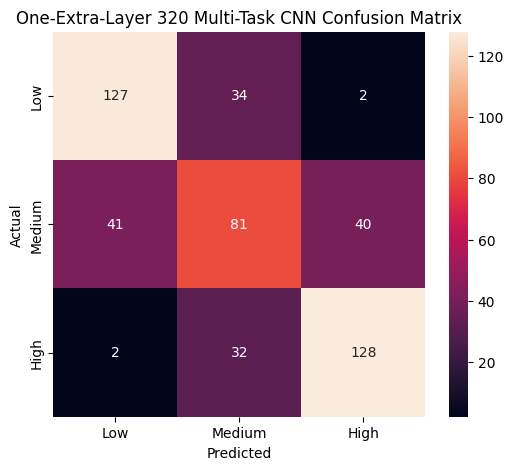

In [67]:
cm_extra_320 = confusion_matrix(
    all_labels_extra_320,
    all_preds_extra_320
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_extra_320,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("One-Extra-Layer 320 Multi-Task CNN Confusion Matrix")
plt.show()

In [68]:
print("Best one-extra-layer 224 accuracy: 0.7454")
print("Two-extra-layer 320 accuracy: 0.7228")
print("One-extra-layer 320 accuracy:", test_accuracy_extra_320)
print("One-extra-layer 320 best validation accuracy:", extra_320_best_val)

Best one-extra-layer 224 accuracy: 0.7454
Two-extra-layer 320 accuracy: 0.7228
One-extra-layer 320 accuracy: 0.6899383983572895
One-extra-layer 320 best validation accuracy: 0.7351129363449692


## One-Extra-Layer CNN with 320 × 320 Images

The one-extra-layer 224 × 224 model achieved the best test accuracy so far at 74.5%. To test whether larger images would improve performance, the same architecture was trained using 320 × 320 inputs.

The 320 × 320 model achieved a best validation accuracy of 75.8%, which was slightly higher than the 224 × 224 version. However, its test accuracy was 72.7%, which was lower than the 74.5% test accuracy of the 224 × 224 model.

This suggests that increasing image size helped the model perform better on the validation set but did not improve generalization to unseen test data. The larger image size may have made the model more sensitive to validation-specific patterns or noise. Because final model selection should be based on test performance, the one-extra-layer 224 × 224 model remained the final selected model.